In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.pyplot import figure

In [2]:
img_size = 128

In [3]:
ids = []

def segmentation_data_loading_cxr(path):
    cxrs = [] 
    for i in tqdm(range(len(ids))):
        image = ids[i]
        if image[0] == 'C':
            image = image[:-9] + image[-4:]
        cxr = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
        cxr = cv2.resize(cxr, (img_size,img_size))
        cxrs.append(cxr)
        
    return np.array(cxrs, dtype = int)

def segmentation_data_loading_mask(path):
    for image in os.listdir(path):
        if image == 'Thumbs.db':
            continue
        ids.append(image)
    ids.sort()
    
    masks = [] 
    for i in tqdm(range(len(ids))):
        image = ids[i]
        mask = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (img_size,img_size))
        masks.append(mask)
        
    return np.array(masks, dtype = int)

In [4]:
masks = segmentation_data_loading_mask('/kaggle/input/chest-xray-masks-and-labels/Lung Segmentation/masks')
cxrs = segmentation_data_loading_cxr('/kaggle/input/chest-xray-masks-and-labels/Lung Segmentation/CXR_png')

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 704/704 [02:14<00:00,  5.24it/s]

(704, 128, 128)
(704, 128, 128)


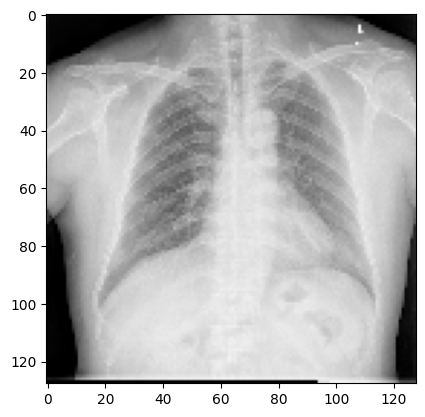

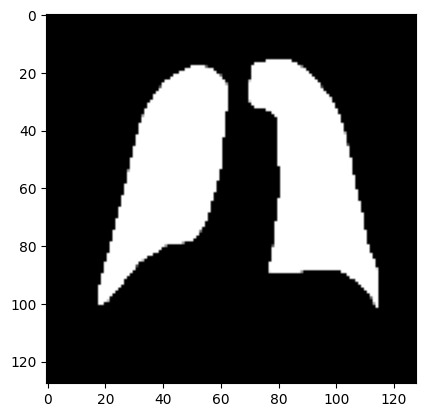

In [5]:
plt.imshow(cxrs[0], cmap='gray')
plt.show()
plt.imshow(masks[0], cmap='gray')
plt.show()

In [6]:
os.makedirs('/kaggle/working/without_convexhull', exist_ok=True)

with open('/kaggle/working/without_convexhull/cxrs', 'wb') as cxrs_file:
    np.save(cxrs_file, cxrs)

with open('/kaggle/working/without_convexhull/masks', 'wb') as masks_file:
    np.save(masks_file, masks)

In [7]:
# !rm -rf /kaggle/working/*

In [8]:
def convexhull_mask(mask):
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    
    points = []
    for i in range(img_size):
        for j in range(img_size):
            if mask[i][j] == 255:
                points.append((j,i))
    points = np.array(points)
    hull = cv2.convexHull(points)
    hulls = np.array([hull])
    
    w,h = mask.shape
    ground = np.zeros((w,h)) 
    figure(figsize = (18,16), dpi = 30)
    cv2.drawContours(ground, hulls, -1, (255,0,0), 3)
    plt.close()
    
    new_mask = np.zeros((img_size,img_size))
    for i in range(img_size):
        minn = img_size + 10
        maxx = 0
        for j in range(img_size):
            if ground[i][j] == 255:
                minn = min(minn, j)
                maxx = max(maxx, j)
        for j in range(minn, maxx + 1):
            new_mask[i][j] = 255

    return new_mask

In [9]:
ids = []

def segmentation_data_loading_cxr(path):
    cxrs = [] 
    for i in tqdm(range(len(ids))):
        image = ids[i]
        if image[0] == 'C':
            image = image[:-9] + image[-4:]
        cxr = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
        cxr = cv2.resize(cxr, (img_size,img_size))
        cxrs.append(cxr)
        
    return np.array(cxrs, dtype = int)

def segmentation_data_loading_mask(path):
    for image in os.listdir(path):
        if image == 'Thumbs.db':
            continue
        ids.append(image)
    ids.sort()
    
    masks = [] 
    for i in tqdm(range(len(ids))):
        image = ids[i]
        mask = cv2.imread(os.path.join(path, image))
        mask = cv2.resize(mask, (img_size,img_size))
        mask = convexhull_mask(mask)
        masks.append(mask)
        
    return np.array(masks, dtype = int)

In [10]:
masks = segmentation_data_loading_mask('/kaggle/input/chest-xray-masks-and-labels/Lung Segmentation/masks')
cxrs = segmentation_data_loading_cxr('/kaggle/input/chest-xray-masks-and-labels/Lung Segmentation/CXR_png')

print(np.shape(cxrs))
print(np.shape(masks))

100%|██████████| 704/704 [01:33<00:00,  7.56it/s]


(704, 128, 128)
(704, 128, 128)


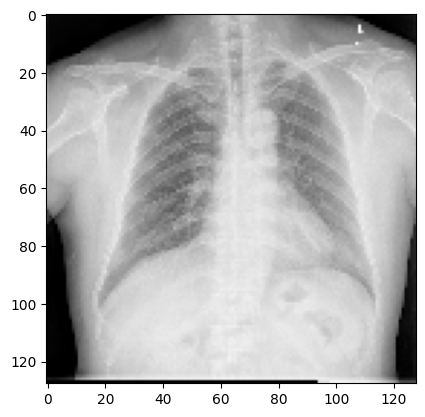

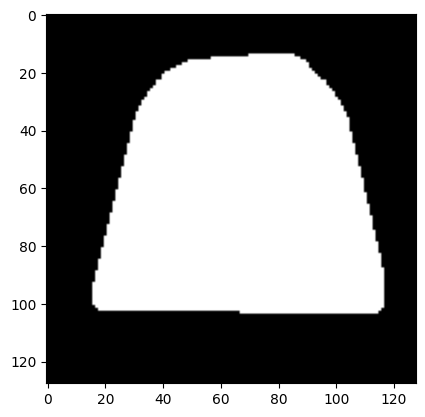

In [11]:
plt.imshow(cxrs[0], cmap='gray')
plt.show()
plt.imshow(masks[0], cmap='gray')
plt.show()

In [12]:
os.makedirs('/kaggle/working/with_convexhull', exist_ok=True)

with open('/kaggle/working/with_convexhull/cxrs', 'wb') as cxrs_file:
    np.save(cxrs_file, cxrs)

with open('/kaggle/working/with_convexhull/masks', 'wb') as masks_file:
    np.save(masks_file, masks)